In [1]:
import os
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import tensorflow as tf
import keras
from tensorflow.keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
path = r"U:\Fruits_New"
cate = ['freshapples' , "freshbanana" ,'freshpomegranate', 'freshwatermelon' ,'freshmango' , "freshoranges" ,
        "rottenapples" ,'rottenmango', 'rottenpomegranate', "rottenbanana" ,'rottenwatermelon' , "rottenoranges" ]

In [3]:
image_size = 224
input_image = []
for i in cate :
    folders = os.path.join(path , i )
    labels = cate.index(i)
    for image in os.listdir(folders):
        image_path = os.path.join (folders , image)
        image_array = cv2.imread(image_path)
        image_array = cv2.resize (image_array, (image_size , image_size))
        input_image.append ([image_array,labels])

In [4]:
len(input_image)

13252

In [5]:
input_image[9000]

[array([[[129, 149, 167],
         [113, 133, 149],
         [ 70,  90, 100],
         ...,
         [ 74, 182, 191],
         [ 74, 187, 194],
         [ 37, 154, 159]],
 
        [[129, 149, 167],
         [114, 134, 149],
         [ 70,  91, 100],
         ...,
         [ 73, 181, 190],
         [ 74, 187, 194],
         [ 38, 155, 160]],
 
        [[130, 149, 167],
         [114, 134, 150],
         [ 71,  91, 101],
         ...,
         [ 73, 181, 189],
         [ 74, 187, 194],
         [ 39, 156, 161]],
 
        ...,
 
        [[147, 152, 153],
         [140, 145, 146],
         [123, 128, 129],
         ...,
         [253, 255, 254],
         [251, 254, 252],
         [250, 253, 251]],
 
        [[192, 197, 198],
         [195, 200, 200],
         [197, 202, 203],
         ...,
         [253, 255, 254],
         [253, 255, 254],
         [253, 255, 254]],
 
        [[239, 244, 245],
         [241, 246, 247],
         [244, 249, 250],
         ...,
         [253, 255, 254],
  

In [7]:
np.random.shuffle(input_image)

In [8]:
input_image_train  = input_image[0: 10600]
input_image_test   = input_image[10600: 13252]

In [9]:
X_train =[]
Y_train = []

for X_values , labels in  input_image_train :
    img_rgb = cv2.cvtColor(X_values, cv2.COLOR_BGR2RGB)
    X_train.append(img_rgb)
    Y_train.append(labels)

In [10]:
X_test =[]
Y_test = []

for X_values , labels in  input_image_test :
    img_rgb = cv2.cvtColor(X_values, cv2.COLOR_BGR2RGB)
    X_test.append(img_rgb)
    Y_test.append(labels)

In [11]:
X_train= np.array(X_train)
Y_train= np.array(Y_train)
X_test= np.array(X_test)
Y_test = np.array (Y_test)

In [12]:
X_train  = X_train/ 255

In [13]:
X_test  = X_test/ 255 

In [14]:
len(X_train)

10600

In [15]:
len(X_test)

2652

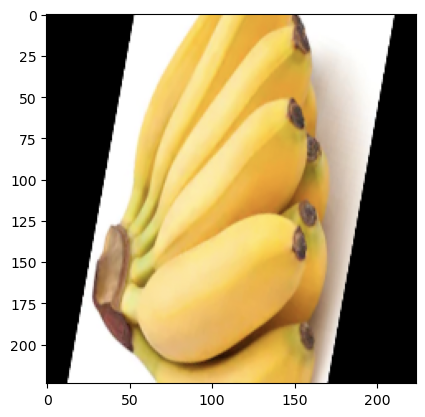

In [16]:
plt.imshow(X_train[9051])

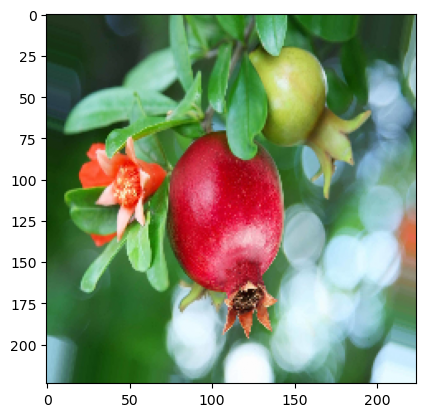

In [17]:
plt.imshow(X_test[900])

In [18]:
model = Sequential()

# Block 1
model.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu', padding='same', input_shape=(image_size, image_size, 3)))
model.add(MaxPool2D(pool_size=(2,2)))
    
# Block 2
model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu', padding='same'))
model.add(MaxPool2D(pool_size=(2,2)))

# Block 3
model.add(Conv2D(filters=128, kernel_size=(3,3), activation='relu', padding='same'))
model.add(MaxPool2D(pool_size=(2,2)))

# Classifier
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.4))       # prevents overfitting
model.add(Dense(128, activation='relu'))
model.add(Dense(12, activation='softmax'))

C:\Users\Udit Gupta\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
adam = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer= adam, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
early_stop = EarlyStopping( monitor='val_accuracy', patience=2, restore_best_weights=True )
history = model.fit( X_train, Y_train, epochs=10, validation_split=0.2, batch_size=32, callbacks=[early_stop])

Epoch 1/10
265/265 ━━━━━━━━━━━━━━━━━━━━ 273s 1s/step - accuracy: 0.4858 - loss: 1.4644 - val_accuracy: 0.7113 - val_loss: 0.8211
Epoch 2/10
265/265 ━━━━━━━━━━━━━━━━━━━━ 257s 968ms/step - accuracy: 0.7827 - loss: 0.6501 - val_accuracy: 0.8580 - val_loss: 0.4210
Epoch 3/10
265/265 ━━━━━━━━━━━━━━━━━━━━ 246s 929ms/step - accuracy: 0.8525 - loss: 0.4435 - val_accuracy: 0.9146 - val_loss: 0.2494
Epoch 4/10
265/265 ━━━━━━━━━━━━━━━━━━━━ 252s 889ms/step - accuracy: 0.8860 - loss: 0.3384 - val_accuracy: 0.9222 - val_loss: 0.2382
Epoch 5/10
265/265 ━━━━━━━━━━━━━━━━━━━━ 251s 946ms/step - accuracy: 0.9132 - loss: 0.2586 - val_accuracy: 0.9377 - val_loss: 0.1753
Epoch 6/10
265/265 ━━━━━━━━━━━━━━━━━━━━ 255s 961ms/step - accuracy: 0.9216 - loss: 0.2228 - val_accuracy: 0.9377 - val_loss: 0.1791
Epoch 7/10
265/265 ━━━━━━━━━━━━━━━━━━━━ 266s 1s/step - accuracy: 0.9394 - loss: 0.1734 - val_accuracy: 0.9481 - val_loss: 0.1514
Epoch 8/10
265/265 ━━━━━━━━━━━━━━━━━━━━ 281s 1s/step - accuracy: 0.9412 - loss: 0.

In [26]:
from sklearn.metrics import confusion_matrix , classification_report

In [27]:
pred=model.predict(X_test)

pred_cat=pred.argmax(axis=1)

83/83 ━━━━━━━━━━━━━━━━━━━━ 14s 166ms/step


In [28]:
tab = confusion_matrix(Y_test,pred.argmax(axis=1))
tab

array([[245,   4,   0,   0,   0,   0,  14,   0,   0,   0,   0,   1],
       [  1, 239,   0,   0,   3,   0,   3,   1,   0,   1,   0,   0],
       [  0,   0, 221,   2,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   2, 191,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   7,   0,   0, 208,   0,   0,   0,   0,   0,   0,   0],
       [  1,   0,   0,   0,   6, 238,   7,   0,   0,   0,   0,   7],
       [  5,   2,   0,   1,   1,   2, 196,   1,   0,   0,   1,   1],
       [  0,   3,   0,   0,   0,   0,   0, 190,   0,   2,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0, 193,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   2,   1,   0, 240,   2,   1],
       [  0,   0,   1,   0,   0,   0,   0,   0,   1,   1, 189,   0],
       [  0,   1,   0,   0,   0,  11,  26,   1,   1,   2,   0, 172]])

In [29]:
print(classification_report(Y_test,pred_cat))

              precision    recall  f1-score   support

           0       0.97      0.93      0.95       264
           1       0.93      0.96      0.95       248
           2       0.99      0.99      0.99       223
           3       0.98      0.99      0.99       193
           4       0.95      0.97      0.96       215
           5       0.95      0.92      0.93       259
           6       0.79      0.93      0.86       210
           7       0.98      0.97      0.98       195
           8       0.99      1.00      0.99       193
           9       0.98      0.98      0.98       246
          10       0.98      0.98      0.98       192
          11       0.95      0.80      0.87       214

    accuracy                           0.95      2652
   macro avg       0.95      0.95      0.95      2652
weighted avg       0.95      0.95      0.95      2652



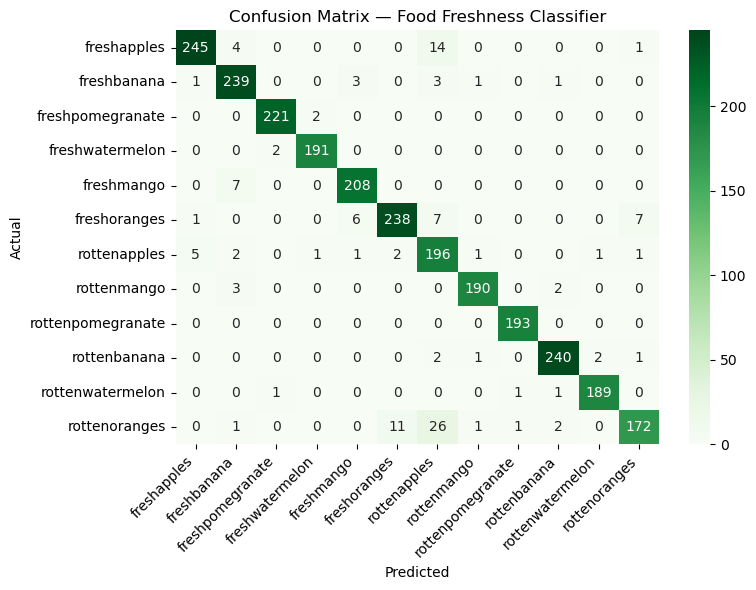

In [30]:
plt.figure(figsize=(8,6))
sns.heatmap(tab, annot = True, fmt = 'd', xticklabels = cate ,yticklabels = cate, cmap = 'Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Food Freshness Classifier')
plt.xticks(rotation = 45, ha ='right')
plt.tight_layout()
plt.show()

In [31]:
model.save('food_freshness_or_rotten_model.keras')
print("Model saved!")

Model saved!


In [32]:
model.save('food_freshness_or_rotten_model.h5')
print("Model saved!")

Model saved!


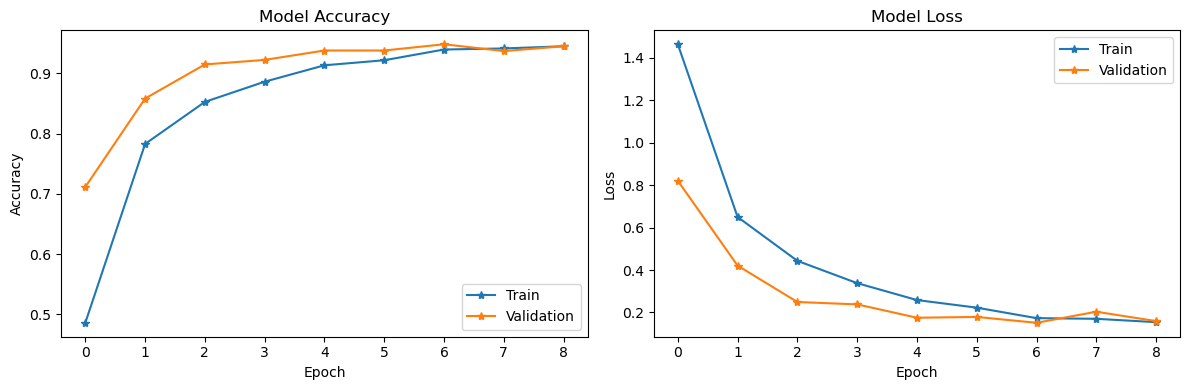

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label = 'Train', marker = '*')
axes[0].plot(history.history['val_accuracy'], label = 'Validation', marker = '*')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label = 'Train', marker = '*')
axes[1].plot(history.history['val_loss'], label = 'Validation', marker = '*')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

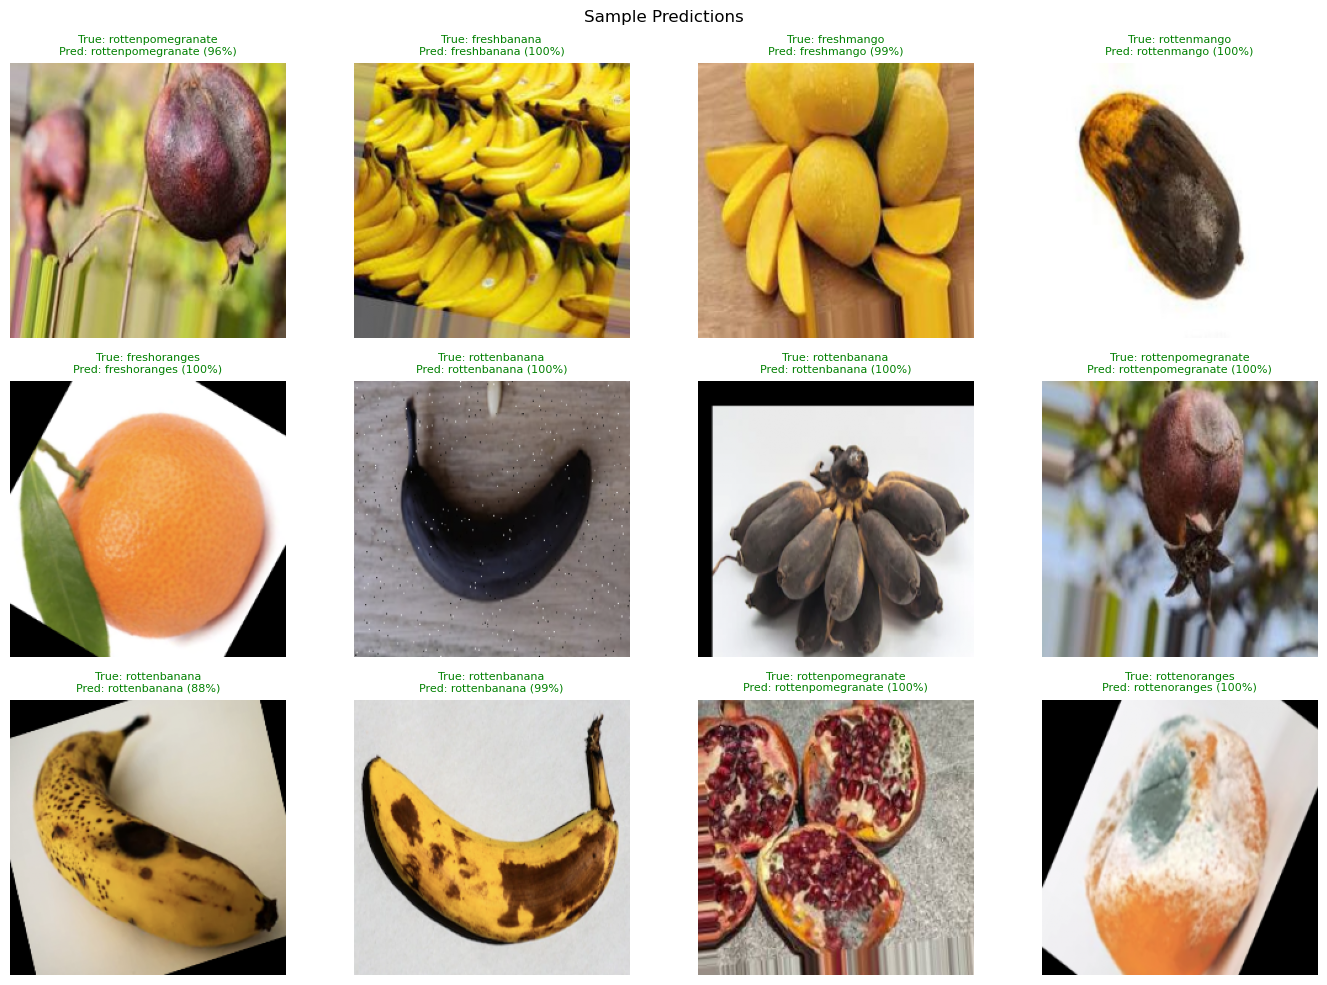

In [34]:
pred_all = model.predict(X_test, verbose=0)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
indices = np.random.randint(0, len(X_test), 12)

for i, ax in zip(indices, axes.flat):
    img = X_test[i]
    true_label = cate[Y_test[i]]
    pred_label = cate[np.argmax(pred_all[i])]
    confidence = np.max(pred_all[i]) * 100

    ax.imshow(img)
    ax.axis('off')
    color = 'green' if pred_label == true_label else 'red'
    ax.set_title(f"True: {true_label}\nPred: {pred_label} ({confidence:.0f}%)", color=color, fontsize=8)

plt.suptitle('Sample Predictions', fontsize=12)
plt.tight_layout()
plt.show()

In [35]:
# TESTING

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step


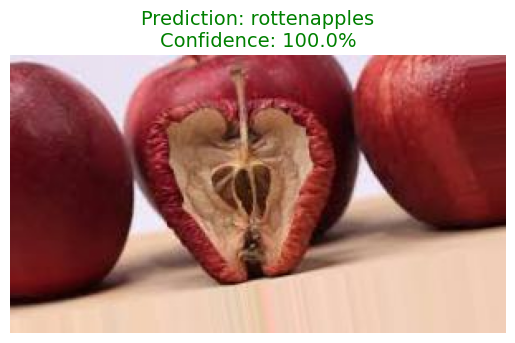

In [36]:
img_path = r"U:\Fruits\rottenapples\dd_0_894.jpeg"
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (224, 224))
img_normalized = img_resized / 255.0
img_input = np.expand_dims(img_normalized, axis=0)

pred_single = model.predict(img_input)[0]
pred_label = cate[np.argmax(pred_single)]
confidence = np.max(pred_single) * 100

# Show image with prediction
plt.imshow(img_rgb)
plt.axis('off')
plt.title(f"Prediction: {pred_label}\nConfidence: {confidence:.1f}%", 
          fontsize=14, color='green')
plt.show()

In [4]:
from tensorflow.keras.models import load_model

model = load_model('food_freshness_or_rotten_model.keras')
adam = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=adam,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
print("Model ready!")

Model ready!


In [37]:
pwd

'C:\\Users\\Udit Gupta\\Capstone projects'